In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import pandas as pd
plt.style.use('default')

Entire the desired output_directory, model_name, and metric we care about. Then run all the code below

In [16]:
output_dir = 'sizes'

output_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs') / output_dir

model_name = 'model_loss'
metrics = ['auc', 'tpr_at_10%', 'tpr_at_20%', 'tpr_at_30%']
# metrics = ['auc']

Parse results into Pandas DF

In [17]:
results = []

for test_dir in output_dir.iterdir():
    if not test_dir.is_dir():
        continue
    for run_dir in test_dir.iterdir():
        if not run_dir.is_dir():
            continue
        
        with open(run_dir / 'test_info' / 'metric_info.json') as f:
            metric_info = json.load(f)

        flat = {
            (model, metric): value
            for model, metrics in metric_info.items()
            for metric, value in metrics.items()
        }

        results.append({
            "test": test_dir.name,
            "run": run_dir.name,
            **flat
        })

df = pd.DataFrame(results).set_index(["test", "run"])

df.columns = pd.MultiIndex.from_tuples(df.columns)
df = df.sort_index(axis=1).sort_index()


In [18]:
df['model_auc']

acc    auc  epoch     f1   fn   fp    fpr   loss   prec  recall  \
test run                                                                       
25   run0  0.863  0.868     -1  0.609   98   43  0.052  0.399  0.719   0.529   
     run1  0.888  0.857     -1  0.669   71   44  0.053  0.379  0.725   0.620   
     run2  0.906  0.910     -1  0.699   58   29  0.038  0.287  0.777   0.635   
     run3  0.728  0.872     -1  0.426   12  274  0.293  0.716  0.279   0.898   
     run4  0.892  0.837     -1  0.331  104   13  0.014  0.290  0.690   0.218   
     run5  0.818  0.872     -1  0.611   59  145  0.161  0.391  0.525   0.731   
     run6  0.925  0.924     -1  0.745   62   27  0.027  0.253  0.828   0.677   
     run7  0.841  0.840     -1  0.521  107   62  0.072  0.395  0.597   0.462   
     run8  0.886  0.821     -1  0.320  125    7  0.007  0.349  0.816   0.199   
     run9  0.877  0.950     -1  0.719   16  113  0.131  0.290  0.594   0.912   
35   run0  0.870  0.874     -1  0.634   92   42  0.051  0.327  0.734   0.558   
     run1  0.883  0.889     -1  0.669   66   54  0.065  0.381  0.691   0.647   
     run2  0.867  0.935     -1  0.682   27   96  0.125  0.298  0.579   0.830   
     run3  0.898  0.926     -1  0.616   32   75  0.080  0.251  0.534   0.729   
     run4  0.929  0.952     -1  0.686   49   28  0.030  0.204  0.750   0.632   
     run5  0.897  0.943     -1  0.753   42   74  0.082  0.258  0.705   0.808   
     run6  0.882  0.950     -1  0.699   28  113  0.113  0.256  0.592   0.854   
     run7  0.848  0.870     -1  0.587   84   78  0.090  0.387  0.596   0.578   
     run8  0.886  0.912     -1  0.629   44   88  0.088  0.293  0.560   0.718   
     run9  0.856  0.930     -1  0.674   25  126  0.146  0.378  0.553   0.862   
50   run0  0.870  0.878     -1  0.647   85   49  0.060  0.320  0.715   0.591   
     run1  0.885  0.883     -1  0.669   68   50  0.060  0.318  0.704   0.636   
     run2  0.878  0.936     -1  0.695   30   83  0.108  0.283  0.608   0.811   
     run3  0.916  0.930     -1  0.669   29   59  0.063  0.225  0.601   0.754   
     run4  0.908  0.934     -1  0.680   28   71  0.075  0.257  0.597   0.789   
     run5  0.871  0.936     -1  0.711   41  104  0.115  0.291  0.631   0.813   
     run6  0.919  0.965     -1  0.773   27   70  0.070  0.201  0.702   0.859   
     run7  0.885  0.897     -1  0.676   72   50  0.058  0.306  0.718   0.638   
     run8  0.919  0.920     -1  0.657   66   28  0.028  0.230  0.763   0.577   
     run9  0.893  0.968     -1  0.750   13   99  0.114  0.240  0.629   0.928   
65   run0  0.863  0.891     -1  0.694   48   93  0.113  0.348  0.632   0.769   
     run1  0.831  0.890     -1  0.620   46  127  0.152  0.393  0.526   0.754   
     run2  0.874  0.948     -1  0.699   23   94  0.123  0.253  0.591   0.855   
     run3  0.876  0.939     -1  0.604   18  113  0.121  0.296  0.469   0.847   
     run4  0.922  0.916     -1  0.704   33   51  0.054  0.216  0.662   0.752   
     run5  0.890  0.916     -1  0.734   49   74  0.082  0.302  0.697   0.776   
     run6  0.908  0.953     -1  0.748   30   79  0.079  0.240  0.672   0.844   
     run7  0.772  0.909     -1  0.594   21  222  0.256  0.502  0.445   0.894   
     run8  0.912  0.924     -1  0.651   61   41  0.041  0.239  0.699   0.609   
     run9  0.914  0.969     -1  0.774   27   63  0.073  0.182  0.710   0.851   
80   run0  0.873  0.906     -1  0.696   58   73  0.089  0.342  0.673   0.721   
     run1  0.857  0.903     -1  0.657   47   99  0.118  0.342  0.586   0.749   
     run2  0.878  0.953     -1  0.705   24   89  0.116  0.277  0.603   0.849   
     run3  0.907  0.946     -1  0.664   21   77  0.082  0.245  0.557   0.822   
     run4  0.901  0.932     -1  0.667   26   81  0.085  0.304  0.569   0.805   
     run5  0.805  0.935     -1  0.642   23  196  0.217  0.419  0.500   0.895   
     run6  0.802  0.940     -1  0.605   11  225  0.225  0.548  0.446   0.943   
     run7  0.874  0.926     -1  0.705   39   95  0.110  0.362  0.627   0.804   
     run8  0.

Average/Variance for desired metrics over all runs for the desired model

In [19]:
m = df[model_name]

stats = m.groupby(level='test').agg(['mean', 'var'])

stats = stats.sort_values(by=('auc', 'mean'), ascending=False)

stats[[(metric, stat) for metric in metrics for stat in ['mean', 'var']]]

auc           tpr_at_10%           tpr_at_20%           tpr_at_30%  \
        mean       var       mean       var       mean       var       mean   
test                                                                          
95    0.9333  0.001009     0.8214  0.006775     0.8996  0.003363     0.9381   
80    0.9279  0.000467     0.7934  0.003749     0.8834  0.001595     0.9360   
65    0.9257  0.000728     0.8031  0.003382     0.8939  0.002387     0.9283   
50    0.9177  0.000918     0.7783  0.005568     0.8683  0.002728     0.9170   
35    0.9106  0.000854     0.7652  0.007886     0.8563  0.002811     0.9029   
25    0.8672  0.001066     0.6422  0.008428     0.7642  0.005813     0.8396   

                
           var  
test            
95    0.002238  
80    0.000576  
65    0.001699  
50    0.001814  
35    0.001321  
25    0.002127

Paired T-test for signficance. Note that it's paired b/c same seed for each 

In [20]:
from scipy.stats import ttest_rel
import pandas as pd
import numpy as np

rows = []

tests = m.index.get_level_values("test").unique()

for metric in metrics:
    # Pull each test's series once
    series_by_test = {}
    for test in tests:
        s = m.loc[test, metric]
        if isinstance(s, pd.DataFrame):
            raise ValueError(f"Expected a Series for test={test}, metric={metric}, got DataFrame.")
        series_by_test[test] = s.dropna()

    # Mean over available runs for ranking
    mean_per_test = pd.Series({
        test: s.mean() for test, s in series_by_test.items() if len(s) > 0
    })

    if mean_per_test.empty:
        continue

    # Best test for this metric
    best_test = mean_per_test.idxmax()
    best_vals = series_by_test[best_test]

    for test in tests:
        if test == best_test:
            continue

        other_vals = series_by_test[test]

        # Align by run/seed so only matching runs are compared
        paired = pd.concat(
            [best_vals.rename("best"), other_vals.rename("other")],
            axis=1,
            join="inner"
        ).dropna()

        n_pairs = len(paired)

        if n_pairs < 2:
            mean_best = np.nan
            mean_test = np.nan
            diff = np.nan
            t_stat = np.nan
            p_value = np.nan
        else:
            mean_best = paired["best"].mean()
            mean_test = paired["other"].mean()
            diff = (paired["best"] - paired["other"]).mean()
            t_stat, p_value = ttest_rel(paired["best"], paired["other"], nan_policy="omit")

        rows.append({
            "metric": metric,
            "best_test": best_test,
            "test": test,
            "mean_best": mean_best,
            "mean_test": mean_test,
            "diff": diff,
            "n_pairs": n_pairs,
            "t_stat": t_stat,
            "p_value": p_value,
            "significant": bool(p_value < 0.05) if pd.notna(p_value) else np.nan,
        })

paired_tstats = (
    pd.DataFrame(rows)
    .set_index(["metric", "best_test", "test"])
    .sort_index()
)

paired_tstats

mean_best  mean_test    diff  n_pairs    t_stat  \
metric     best_test test                                                    
auc        95        25       0.9333     0.8672  0.0661       10  7.080833   
                     35       0.9333     0.9106  0.0227       10  2.721802   
                     50       0.9333     0.9177  0.0156       10  2.324822   
                     65       0.9333     0.9257  0.0076       10  2.373970   
                     80       0.9333     0.9279  0.0054       10  0.921228   
tpr_at_10% 95        25       0.8214     0.6422  0.1792       10  5.654388   
                     35       0.8214     0.7652  0.0562       10  2.296491   
                     50       0.8214     0.7783  0.0431       10  2.536030   
                     65       0.8214     0.8031  0.0183       10  1.480538   
                     80       0.8214     0.7934  0.0280       10  1.575068   
tpr_at_20% 95        25       0.8996     0.7642  0.1354       10  5.781634   
                     35       0.8996     0.8563  0.0433       10  2.762074   
                     50       0.8996     0.8683  0.0313       10  3.705331   
                     65       0.8996     0.8939  0.0057       10  0.829462   
                     80       0.8996     0.8834  0.0162       10  1.431916   
tpr_at_30% 95        25       0.9381     0.8396  0.0985       10  6.820189   
                     35       0.9381     0.9029  0.0352       10  2.974046   
                     50       0.9381     0.9170  0.0211       10  2.834578   
                     65       0.9381     0.9283  0.0098       10  1.729531   
                     80       0.9381     0.9360  0.0021       10  0.218375   

                            p_value  significant  
metric     best_test test                         
auc        95        25    0.000058         True  
                     35    0.023538         True  
                     50    0.045128         True  
                     65    0.041637         True  
                     80    0.380962        False  
tpr_at_10% 95        25    0.000312         True  
                     35    0.047270         True  
                     50    0.031918         True  
                     65    0.172865        False  
                     80    0.149694        False  
tpr_at_20% 95        25    0.000266         True  
                     35    0.022037         True  
                     50    0.004880         True  
                     65    0.428294        False  
                     80    0.185967        False  
tpr_at_30% 95        25    0.000077         True  
                     35    0.015600         True  
                     50    0.019576         True  
                     65    0.117772        False  
                     80    0.832008        False

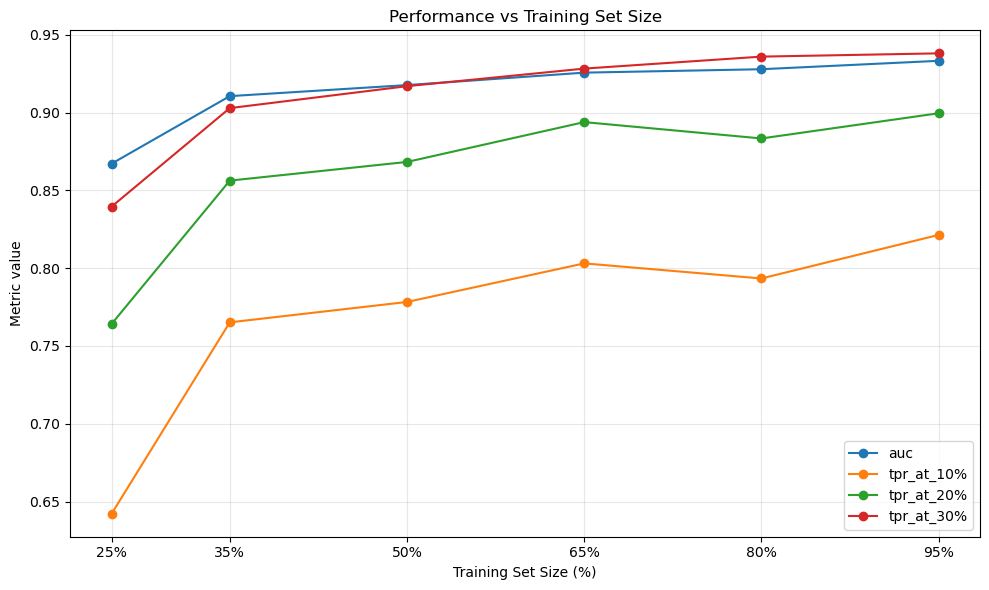

In [21]:
if output_dir.stem == 'sizes':
    m = df[model_name]

    stats = m.groupby(level="test").agg(["mean", "var"])
    stats = stats.sort_index()  # sort by test size for plotting

    plt.figure(figsize=(10, 6))

    for metric in metrics:
        y = stats[(metric, "mean")]
        x = y.index.astype(float)

        plt.plot(
            x,
            y.values,
            marker="o",
            label=metric
        )

    xticks = stats.index.astype(float)
    plt.xticks(xticks, [f"{int(x)}%" for x in xticks])

    plt.xlabel("Training Set Size (%)")
    plt.ylabel("Metric value")
    plt.title("Performance vs Training Set Size")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../../thesis_figs/figs/training_size.png')